# Task 4: Adversarial Robustness Testing

This notebook follows the task requirements for FGSM, PGD, adversarial training, robustness benchmarking, and per-emotion perturbation visualization.


In [1]:
import ssl
import sys
from pathlib import Path
from urllib.error import URLError

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torchvision.models import ResNet18_Weights, resnet18

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.core.dataset import get_dataloaders
from src.task_4_adversarial.attacks import fgsm_attack, pgd_attack
from src.task_4_adversarial.evaluate import evaluate
from src.task_4_adversarial.train_robust import train_robust

emotion_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
FGSM_EPS = 8 / 255
PGD_EPS = 8 / 255
PGD_ALPHA = 1 / 255
PGD_STEPS = 10


In [2]:
class EmotionModel(nn.Module):
    def __init__(self):
        super().__init__()

        try:
            backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
            print("Loaded ImageNet-pretrained ResNet18 weights.")
        except (URLError, ssl.SSLError, RuntimeError) as exc:
            print(f"Could not download pretrained weights ({exc}). Falling back to randomly initialized ResNet18.")
            backbone = resnet18(weights=None)

        backbone.fc = nn.Linear(backbone.fc.in_features, len(emotion_names))
        self.model = backbone

    def forward(self, x):
        return self.model(x)

model = EmotionModel().to(device)
print(f"Using device: {device}")


Could not download pretrained weights (<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)>). Falling back to randomly initialized ResNet18.
Using device: mps


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/bsama/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


In [3]:
train_loader, test_loader = get_dataloaders(
    PROJECT_ROOT / "data" / "raw" / "train",
    PROJECT_ROOT / "data" / "raw" / "test",
    batch_size=32,
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

print("Training standard classifier on FER2013 with cross-entropy loss...")
model.train()
for epoch in range(5):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch + 1}/5 | loss={running_loss / len(train_loader):.4f}")


Training standard classifier on FER2013 with cross-entropy loss...
Epoch 1/5 | loss=1.8399
Epoch 2/5 | loss=1.8027
Epoch 3/5 | loss=1.6959
Epoch 4/5 | loss=1.5138
Epoch 5/5 | loss=1.3758


In [4]:
def benchmark_model(model, loader, device):
    rows = []
    rows.append({"setting": "clean", "accuracy": evaluate(model, loader, device)})
    rows.append({
        "setting": f"fgsm eps={FGSM_EPS:.5f}",
        "accuracy": evaluate(model, loader, device, attack="fgsm", attack_kwargs={"eps": FGSM_EPS}),
    })
    rows.append({
        "setting": f"pgd eps={PGD_EPS:.5f} alpha={PGD_ALPHA:.5f} steps={PGD_STEPS}",
        "accuracy": evaluate(
            model,
            loader,
            device,
            attack="pgd",
            attack_kwargs={"eps": PGD_EPS, "alpha": PGD_ALPHA, "steps": PGD_STEPS},
        ),
    })
    return pd.DataFrame(rows)

print("Benchmark before adversarial training")
standard_benchmark = benchmark_model(model, test_loader, device)
standard_benchmark


Benchmark before adversarial training


,setting,accuracy
0,clean,0.491084
1,fgsm eps=0.03137,0.236417
2,pgd eps=0.03137 alpha=0.00392 steps=10,0.146141


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


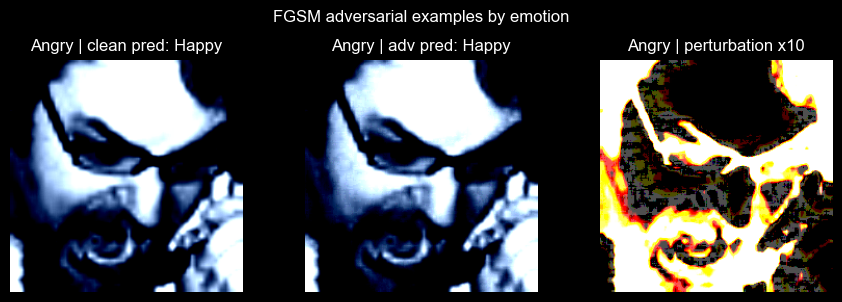

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


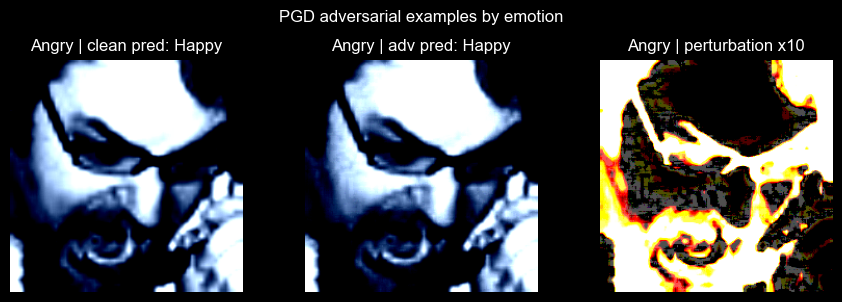

In [5]:
def visualize_adversarial_examples(model, loader, device, class_names, attack_type="fgsm"):
    model.eval()
    images, labels = next(iter(loader))
    images = images.to(device)
    labels = labels.to(device)

    if attack_type == "fgsm":
        adv_images = fgsm_attack(model, images, labels, eps=FGSM_EPS)
    else:
        adv_images = pgd_attack(model, images, labels, eps=PGD_EPS, alpha=PGD_ALPHA, steps=PGD_STEPS)

    with torch.no_grad():
        clean_preds = model(images).argmax(dim=1)
        adv_preds = model(adv_images).argmax(dim=1)

    images = images.cpu()
    adv_images = adv_images.cpu()
    labels = labels.cpu()
    clean_preds = clean_preds.cpu()
    adv_preds = adv_preds.cpu()

    unique_labels = []
    for idx, label in enumerate(labels.tolist()):
        if label not in unique_labels:
            unique_labels.append(label)
        if len(unique_labels) == 3:
            break

    chosen_indices = []
    for label in unique_labels:
        chosen_indices.append((labels == label).nonzero(as_tuple=False)[0].item())

    fig, axes = plt.subplots(len(chosen_indices), 3, figsize=(9, 3 * len(chosen_indices)))
    if len(chosen_indices) == 1:
        axes = [axes]

    for row, idx in enumerate(chosen_indices):
        perturbation = (adv_images[idx] - images[idx]) * 10
        emotion = class_names[labels[idx].item()]
        clean_pred = class_names[clean_preds[idx].item()]
        adv_pred = class_names[adv_preds[idx].item()]

        axes[row][0].imshow(images[idx].permute(1, 2, 0))
        axes[row][0].set_title(f"{emotion} | clean pred: {clean_pred}")
        axes[row][0].axis("off")

        axes[row][1].imshow(adv_images[idx].permute(1, 2, 0))
        axes[row][1].set_title(f"{emotion} | adv pred: {adv_pred}")
        axes[row][1].axis("off")

        axes[row][2].imshow(perturbation.permute(1, 2, 0))
        axes[row][2].set_title(f"{emotion} | perturbation x10")
        axes[row][2].axis("off")

    fig.suptitle(f"{attack_type.upper()} adversarial examples by emotion", y=0.99)
    plt.tight_layout()
    plt.show()

visualize_adversarial_examples(model, test_loader, device, emotion_names, attack_type="fgsm")
visualize_adversarial_examples(model, test_loader, device, emotion_names, attack_type="pgd")


In [6]:
print("Running adversarial training with PGD examples on roughly 10% of batches...")
train_robust(
    model,
    train_loader,
    device,
    epochs=5,
    adv_fraction=0.1,
    attack_kwargs={"eps": PGD_EPS, "alpha": PGD_ALPHA, "steps": PGD_STEPS},
)


Running adversarial training with PGD examples on roughly 10% of batches...
[Robust Train] Epoch 1 | Loss: 1.3688
[Robust Train] Epoch 2 | Loss: 1.2958
[Robust Train] Epoch 3 | Loss: 1.2469
[Robust Train] Epoch 4 | Loss: 1.2094
[Robust Train] Epoch 5 | Loss: 1.1850


In [7]:
print("Benchmark after adversarial training")
robust_benchmark = benchmark_model(model, test_loader, device)
comparison = standard_benchmark.rename(columns={"accuracy": "before_adv_training"}).merge(
    robust_benchmark.rename(columns={"accuracy": "after_adv_training"}),
    on="setting",
)
comparison["delta"] = comparison["after_adv_training"] - comparison["before_adv_training"]
comparison


Benchmark after adversarial training


,setting,before_adv_training,after_adv_training,delta
0,clean,0.491084,0.575369,0.084285
1,fgsm eps=0.03137,0.236417,0.320424,0.084007
2,pgd eps=0.03137 alpha=0.00392 steps=10,0.146141,0.184870,0.038729


## Checklist Coverage

- Standard FER2013 classifier training with cross-entropy loss.
- FGSM implemented with `eps = 8/255`.
- PGD implemented with `eps = 8/255`, `alpha = 1/255`, `steps = 10`.
- Robustness measured before and after adversarial training.
- Adversarial training uses PGD examples for roughly 10% of training batches.
- Clean, FGSM, and PGD accuracy are benchmarked side by side.
- Visualizations are labeled by emotion to show prediction flips under perturbation.
